# Ex3_0_RandomVariablesExperiments-solution

In [19]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from mpl_toolkits.mplot3d import Axes3D

## 1 Random Variables experiments
Prof. Maurizio Tognolini - 2026 HEIG-VD - MSE - Statistical Digital Signal Processing rev 1.1 -
2026-02-15

Générer une matrice `X` contenant des valeurs entières de 1 à 6, simulant des lancers de dés (distribution uniforme).

**Structure de la matrice (`X.shape = (50, 100)`) :**
- **Lignes (`NR = 50`) :** Le nombre de réalisations (expériences indépendantes).
- **Colonnes (`N = 100`) :** Le nombre d'échantillons temporels (lancers successifs).

**Méthode demandée :**
L'énoncé suggère d'utiliser `rand()` (qui génère des flottants entre 0 et 1). En Python avec NumPy, la formule exacte est :
`X = np.floor(np.random.rand(NR, N) * 6) + 1`

*(Note : La méthode Python la plus directe et moderne serait `X = np.random.randint(1, 7, size=(NR, N))`)*

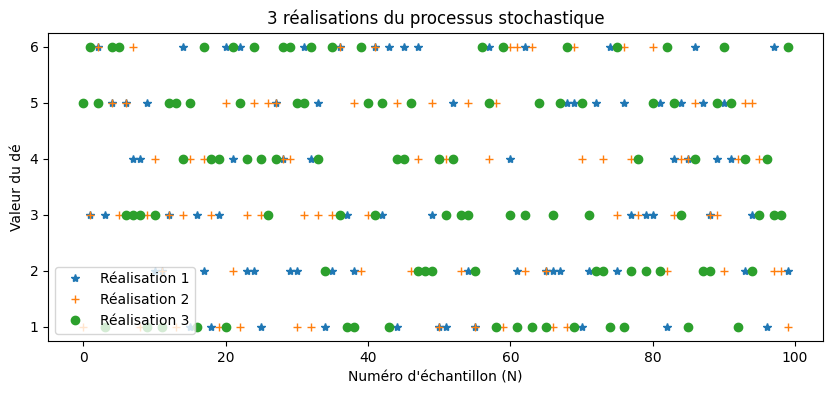

In [2]:
N = 100  # Échantillons temporels
NR = 50  # Réalisations (expériences)

# Génération directe d'entiers entre 1 et 6
x = np.random.randint(1, 7, size=(NR, N))

# Affichage de 3 réalisations
plt.figure(figsize=(10, 4))
plt.plot(x[0, :], '*', label='Réalisation 1')
plt.plot(x[1, :], '+', label='Réalisation 2')
plt.plot(x[2, :], 'o', label='Réalisation 3')
plt.legend()
plt.xlabel("Numéro d'échantillon (N)")
plt.ylabel('Valeur du dé')
plt.title('3 réalisations du processus stochastique')
plt.show()

Générer une matrice `Y` simulant un processus gaussien (bruit blanc normal), centré sur 0 (moyenne $\mu = 0$) et avec un écart-type de 3 ($\sigma = 3$).

**Structure de la matrice (`Y.shape = (50, 100)`) :**
- **Lignes (`NR = 50`) :** Le nombre de réalisations (expériences indépendantes).
- **Colonnes (`N = 100`) :** Le nombre d'échantillons temporels.

**Méthode demandée :**
L'énoncé suggère d'utiliser `randn()`, qui génère une loi normale standard $\mathcal{N}(0,1)$. Pour lui appliquer l'écart-type de 3 (noté $A$ dans ton énoncé), la formule mathématique en code est :
`Y = 3 * np.random.randn(NR, N)`

*(Note : En appliquant les bonnes pratiques de ton guide NumPy, la méthode Python moderne et plus explicite serait `Y = np.random.normal(loc=0.0, scale=3.0, size=(NR, N))`)*

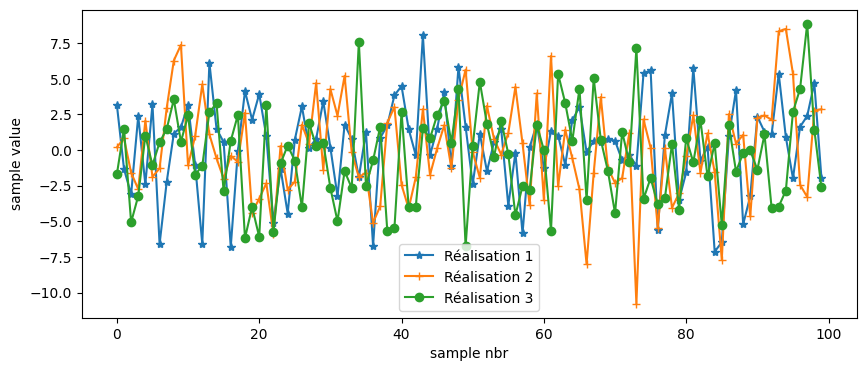

In [3]:
A = 3
# Génération d'un processus normal (Gaussien)
y = A * np.random.randn(NR, N)
# Affichage de 3 réalisations
plt.figure(figsize=(10, 4))
plt.plot(y[0, :], '-*', label='Réalisation 1')
plt.plot(y[1, :], '-+', label='Réalisation 2')
plt.plot(y[2, :], '-o', label='Réalisation 3')
plt.legend()
plt.xlabel('sample nbr')
plt.ylabel('sample value')
plt.show()

### 1.1 First order moments in Realization space
Calculer les statistiques de base (moyenne et variance/écart-type) séparément pour *chaque* réalisation du processus (pour les dés comme pour le bruit gaussien).

**Le concept théorique visé :**
Il s'agit de calculer la **moyenne temporelle** (et la variance temporelle). Pour une réalisation donnée (une ligne fixe de ta matrice), tu calcules la statistique sur l'ensemble de ses 100 échantillons temporels (les colonnes).
- Tu pars d'une matrice de dimension `(50, 100)`.
- Tu dois écraser la dimension temporelle pour obtenir un vecteur de dimension `(50,)` contenant les 50 résultats.

**Méthode demandée (Python/NumPy) :**
Le secret ici est de ne pas faire de boucle `for`, mais d'utiliser l'argument `axis=1` des fonctions NumPy pour forcer le calcul le long de l'axe des échantillons.

Pour une matrice `X` (ou `Y`) :
- Moyennes : `moyennes = np.mean(X, axis=1)`
- Écarts-types (std) : `ecarts_types = np.std(X, axis=1)`
- Variances : `variances = np.var(X, axis=1)`

*(Note : L'énoncé demande d'abord la "variance" puis mentionne "std" (standard deviation / écart-type) juste après. En pratique, la variance est le carré de l'écart-type, tu peux calculer `np.std()` et l'élever au carré si besoin).*

In [5]:
# 1. Calcul des moments temporels (sur l'axe 1 : par réalisation)
mu_x = np.mean(x, axis=1)
std_x = np.std(x, axis=1, ddof=1)

mu_y = np.mean(y, axis=1)
std_y = np.std(y, axis=1, ddof=1)

# 2. Affichage propre des 8 premières réalisations (Dés)
# Utilisation de zip() pour itérer proprement sur deux listes à la fois
print("--- Statistiques des 8 premières réalisations (Dés) ---")
print(f"{'Réalisation':<12} | {'Moyenne':<10} | {'Écart-type':<10}")
print("-" * 40)
for i, (m, s) in enumerate(zip(mu_x[:8], std_x[:8]), start=1):
    print(f"{i:<12} | {m:<10.4f} | {s:<10.4f}")
print("\n")

# 3. Statistiques d'ensemble (Évaluation de nos estimateurs)
# On calcule l'Espérance (moyenne) et la dispersion (std) de nos estimations
print("--- Propriétés des estimateurs d'ensemble (Dés) ---")
print(f"E[mu_x]   = {np.mean(mu_x):.4f}  (Théorique : 3.5)")
print(f"Std[mu_x] = {np.std(mu_x, ddof=1):.4f}")
print(f"E[std_x]  = {np.mean(std_x):.4f}")
print(f"Std[std_x]= {np.std(std_x, ddof=1):.4f}")

--- Statistiques des 8 premières réalisations (Dés) ---
Réalisation  | Moyenne    | Écart-type
----------------------------------------
1            | 3.5800     | 1.7418    
2            | 3.3400     | 1.6405    
3            | 3.6000     | 1.7350    
4            | 3.2300     | 1.7515    
5            | 3.7600     | 1.6213    
6            | 3.4900     | 1.6967    
7            | 3.3900     | 1.8029    
8            | 3.7200     | 1.6458    


--- Propriétés des estimateurs d'ensemble (Dés) ---
E[mu_x]   = 3.5202  (Théorique : 3.5)
Std[mu_x] = 0.1645
E[std_x]  = 1.7189
Std[std_x]= 0.0655


Calculer la moyenne et l'écart-type (temporels) pour chaque réalisation (chaque ligne) du processus Gaussien `y`.

**Le concept théorique visé :**
C'est exactement le même principe que pour l'exercice précédent avec les dés, appliqué cette fois-ci à ton bruit blanc. L'objectif est de vérifier empiriquement que les estimateurs temporels d'un processus Gaussien reflètent bien les paramètres théoriques utilisés pour le générer (ici, $\mu = 0$ et $\sigma = 3$).

**Méthode demandée (Rappel) :**
On utilise toujours `axis=1` pour calculer la statistique sur les 100 échantillons de chaque réalisation, et on n'oublie pas le `ddof=1`.

*(Note : Le code correspondant à cette consigne a déjà été intégré dans le bloc Python précédent avec les variables `mu_y` et `std_y`)*

In [6]:
# --- Calcul des moments du premier ordre pour y ---
# muyR : Moyenne de chaque réalisation (moyenne par ligne)
# stdyR : Écart-type de chaque réalisation (std par ligne)
# ddof=1 pour correspondre au calcul non biaisé de MATLAB
muyR = np.mean(y, axis=1)
stdyR = np.std(y, axis=1, ddof=1)
# --- Affichage des 8 premières réalisations ---
print(f"{'Réalisation':<15} | {'Moyenne (muyR)':<18} | {'Écart-type (stdyR)':<20}")
print("-" * 60)
for i in range(8):
    print(f"{i+1:<15} | {muyR[i]:<18.4f} | {stdyR[i]:<20.4f}")
# Moyenne des estimations (Espérance de la moyenne)
E_m_y = np.mean(muyR)
Std_m_y = np.std(muyR, ddof=1) # Écart-type de la moyenne estimée
print(f"E[muyR] = {E_m_y:.4f}, Std[muyR] = {Std_m_y:.4f}")

Réalisation     | Moyenne (muyR)     | Écart-type (stdyR)  
------------------------------------------------------------
1               | 0.3146             | 3.2278              
2               | 0.0383             | 3.4754              
3               | -0.3950            | 3.2851              
4               | -0.0904            | 3.1346              
5               | -0.4732            | 3.1155              
6               | 0.4161             | 3.1120              
7               | 0.3589             | 2.8230              
8               | -0.0043            | 2.9101              
E[muyR] = 0.0011, Std[muyR] = 0.2729


Calcul de la moyenne pour chaque réalisation (déjà effectué précédemment) muyR = np.mean(y,
axis=1)

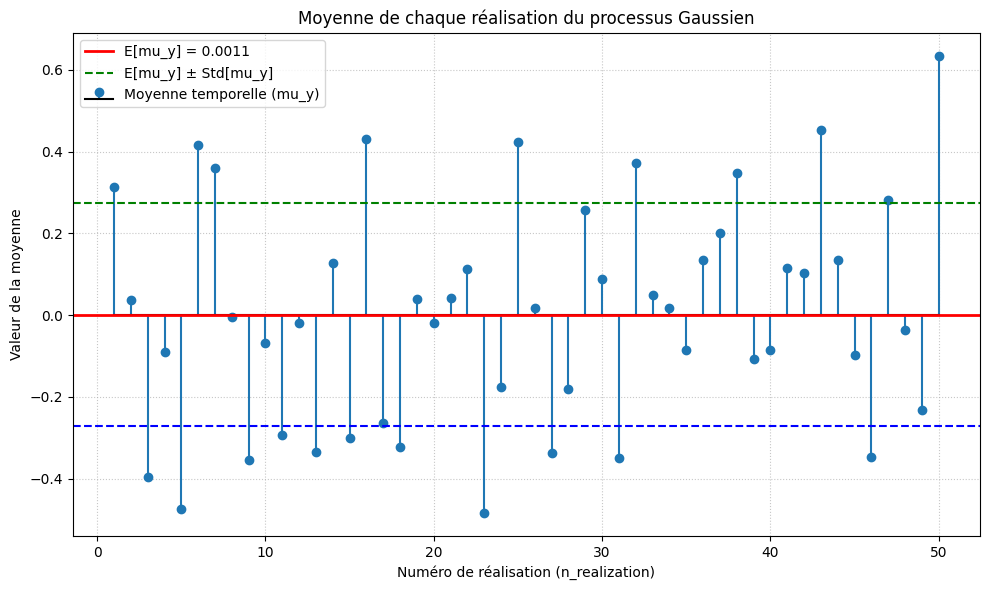

In [8]:
# Calcul des statistiques d'ensemble pour le processus Gaussien
E_mu_y = np.mean(mu_y)
Std_mu_y = np.std(mu_y, ddof=1)

# Axe des abscisses (1 à NR)
n_realization = np.arange(1, NR + 1)

plt.figure(figsize=(10, 6))

# Tracé des moyennes de chaque réalisation (stem plot)
plt.stem(n_realization, mu_y, basefmt="k-", label='Moyenne temporelle (mu_y)')

# Tracé de l'Espérance (moyenne des moyennes)
plt.axhline(E_mu_y, color='red', linestyle='-', linewidth=2, 
            label=f'E[mu_y] = {E_mu_y:.4f}')

# Tracé des bornes de dispersion (+/- 1 écart-type)
plt.axhline(E_mu_y + Std_mu_y, color='green', linestyle='--', 
            label=f'E[mu_y] ± Std[mu_y]')
plt.axhline(E_mu_y - Std_mu_y, color='blue', linestyle='--')

# Mise en forme du graphique
plt.xlabel('Numéro de réalisation (n_realization)')
plt.ylabel('Valeur de la moyenne')
plt.title('Moyenne de chaque réalisation du processus Gaussien')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Calcul de l’écart-type pour chaque réalisation du processus y

In [9]:
# ddof=1 pour correspondre au calcul non biaisé (N-1) de MATLAB
stdyR = np.std(y, axis=1, ddof=1)

# Affichage des 8 premières valeurs avec 4 décimales
print(f"{'Réalisation':<15} | {'Écart-type (stdyR)':<20}")
print("-" * 40)

for i in range(8):
    print(f"{i+1:<15} | {stdyR[i]:<20.4f}")
    
# Moyenne des estimations (Espérance de la deviation standard)
E_std_y = np.mean(stdyR)
# variation standard de l'estimation de la deviation standard
Std_std_y = np.std(stdyR, ddof=1)
print(f"E[stdxy] = {E_std_y:.4f}, Std[stdxy] = {Std_std_y:.4f}")

Réalisation     | Écart-type (stdyR)  
----------------------------------------
1               | 3.2278              
2               | 3.4754              
3               | 3.2851              
4               | 3.1346              
5               | 3.1155              
6               | 3.1120              
7               | 2.8230              
8               | 2.9101              
E[stdxy] = 2.9795, Std[stdxy] = 0.2103


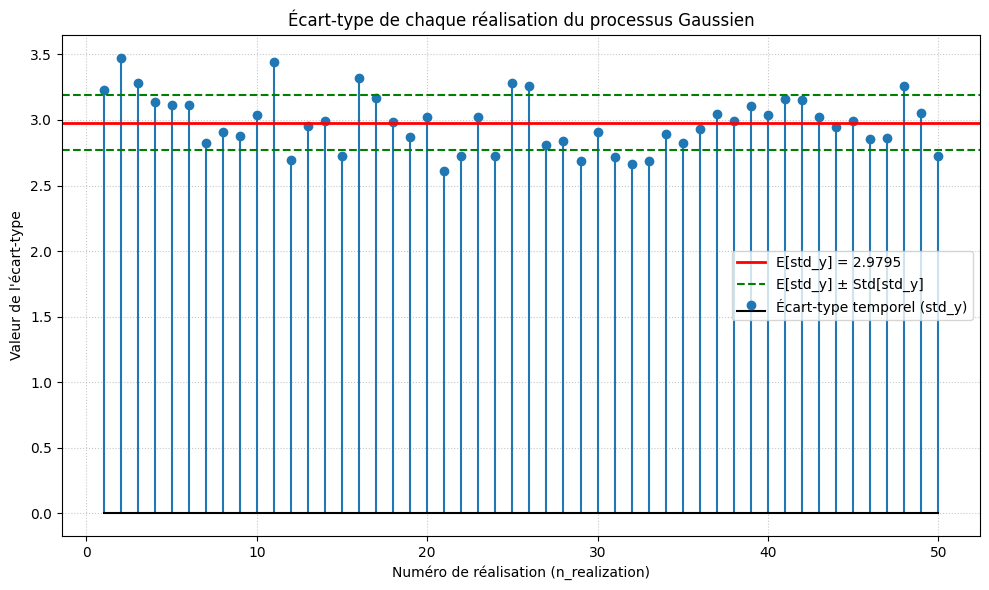

In [10]:
# Calcul des statistiques d'ensemble pour l'écart-type du processus Gaussien
E_std_y = np.mean(std_y)
Std_std_y = np.std(std_y, ddof=1)

plt.figure(figsize=(10, 6))

# Tracé des écarts-types de chaque réalisation (stem plot)
plt.stem(n_realization, std_y, basefmt="k-", label="Écart-type temporel (std_y)")

# Tracé de l'Espérance (moyenne des écarts-types)
# La valeur théorique attendue est proche de sigma = 3
plt.axhline(E_std_y, color='red', linestyle='-', linewidth=2, 
            label=f'E[std_y] = {E_std_y:.4f}')

# Tracé des bornes de dispersion (+/- 1 écart-type de l'estimateur)
# J'utilise une seule couleur pour les bornes pour plus de lisibilité
plt.axhline(E_std_y + Std_std_y, color='green', linestyle='--', 
            label=f'E[std_y] ± Std[std_y]')
plt.axhline(E_std_y - Std_std_y, color='green', linestyle='--')

# Mise en forme du graphique
plt.xlabel('Numéro de réalisation (n_realization)')
plt.ylabel("Valeur de l'écart-type")
plt.title('Écart-type de chaque réalisation du processus Gaussien')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.2 Estimation of the density of probability by the hysrogram:
Estimer la densité de probabilité du processus `x` (les lancers de dés) en calculant un histogramme global sur l'intégralité des données (toutes les réalisations et tous les échantillons confondus).

**Le concept théorique visé :**
Un histogramme classique se contente de compter le nombre d'apparitions de chaque valeur. Pour transformer ce comptage brut en une **densité de probabilité estimée** (`pxEst`), il faut le normaliser. En divisant les comptes par le nombre total d'échantillons générés ($N \times NR$), on s'assure que la somme des probabilités vaut exactement 1.

**Plan d'attaque en Python :**
1. Aplatir la matrice 2D `x` en un vecteur 1D (pour que l'histogramme prenne tout en compte d'un coup) en utilisant `.flatten()`.
2. Compter les occurrences de chaque face avec `np.histogram()`.
3. Diviser le tableau des comptes par `(N * NR)`.

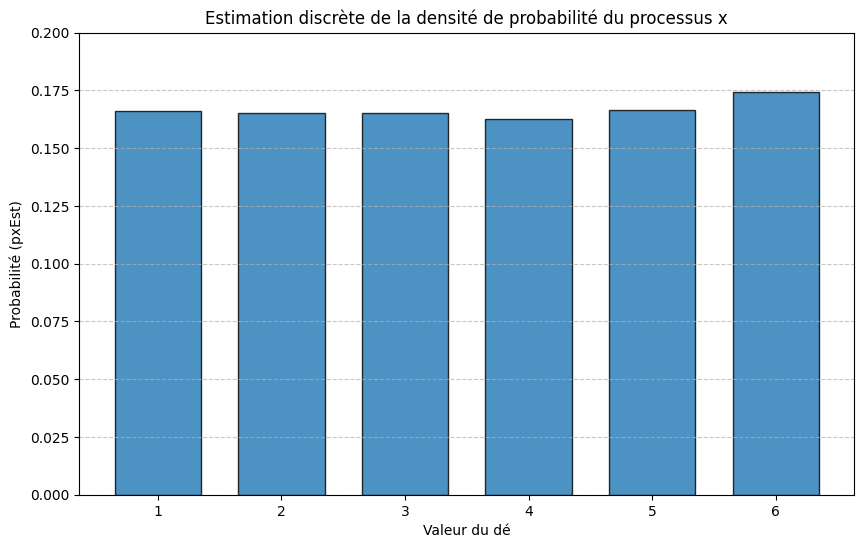

In [11]:
# 1. Calcul de l'histogramme sur l'ensemble des échantillons (N * NR)
# x.flatten() ou x.ravel() permet d'accéder à toutes les valeurs
# On définit les bacs (bins) pour centrer les valeurs sur [1, 2, 3, 4, 5, 6]
bins = np.arange(1, 8) # Créé [1, 2, 3, 4, 5, 6, 7] pour délimiter les faces
counts, bin_edges = np.histogram(x.flatten(), bins=bins)
# 2. Estimation de la densité de probabilité discrète (pxEst)
# On divise le nombre d'occurrences par le nombre total d'échantillons
pxEst = counts / (N * NR)
# 3. Affichage graphique (équivalent à bar en Matlab)
plt.figure(figsize=(10, 6))
plt.bar(np.arange(1, 7), pxEst, width=0.7, edgecolor='black', alpha=0.8)
# Configuration des axes et titres
plt.xlabel('Valeur du dé')
plt.ylabel('Probabilité (pxEst)')
plt.title('Estimation discrète de la densité de probabilité du processus x')
plt.xticks(np.arange(1, 7))
plt.ylim(0, 0.20) # Ajusté pour correspondre au graphique
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Vérifier que la distribution estimée est bien une probabilité valide. La somme de toutes les valeurs de ton histogramme normalisé (`pxEst`) doit être exactement égale à 1, ce qui correspond à l'intégrale d'une densité de probabilité. On te demande de le prouver avec la fonction `sum()`.

**Le concept théorique visé :**
C'est le deuxième axiome des probabilités (axiome de normalisation) : la somme des probabilités de toutes les issues possibles d'une expérience aléatoire est toujours égale à 1 (ou 100 %). En traitement du signal, c'est ce qui différencie un simple histogramme de comptage d'une véritable **Densité de Probabilité (PDF)**.

**Méthode demandée en Python :**
Utiliser `np.sum()` sur le vecteur contenant les probabilités estimées.

In [13]:
# Vérification : La somme doit être égale à 1
integral_pxEst = np.sum(pxEst)
print(f"Somme de pxEst (Intégrale) : {integral_pxEst:.4f}")

Somme de pxEst (Intégrale) : 1.0000


Calculer l'histogramme du processus gaussien `y` en utilisant la totalité des échantillons (toutes les réalisations confondues). Cet histogramme est l'estimation discrète de la densité de probabilité $p_y$ (que l'on nommera `pyEst`). Pour l'obtenir, il faut diviser les comptes bruts de l'histogramme par le nombre total d'échantillons générés ($N \times NR$).

**Le concept théorique visé :**
On applique exactement la même logique que pour les lancers de dés, mais cette fois sur une variable continue (le bruit blanc gaussien). Pour estimer empiriquement sa Densité de Probabilité (PDF), on écrase toutes les dimensions pour regrouper nos 5000 valeurs de bruit, on les classe dans des intervalles (bins), et on normalise les effectifs par la taille totale de l'échantillon. Cela permet d'observer la fameuse courbe en "cloche".

**Plan d'attaque (Rappel de la méthode Python) :**
1. Aplatir la matrice : `y.flatten()`
2. Compter les occurrences dans des intervalles : `counts, bins = np.histogram(y.flatten(), bins=100)`
3. Normaliser pour obtenir la probabilité : `pyEst = counts / (N * NR)`

Somme de pxEst : 1.0000 (Attendue : 1.0)


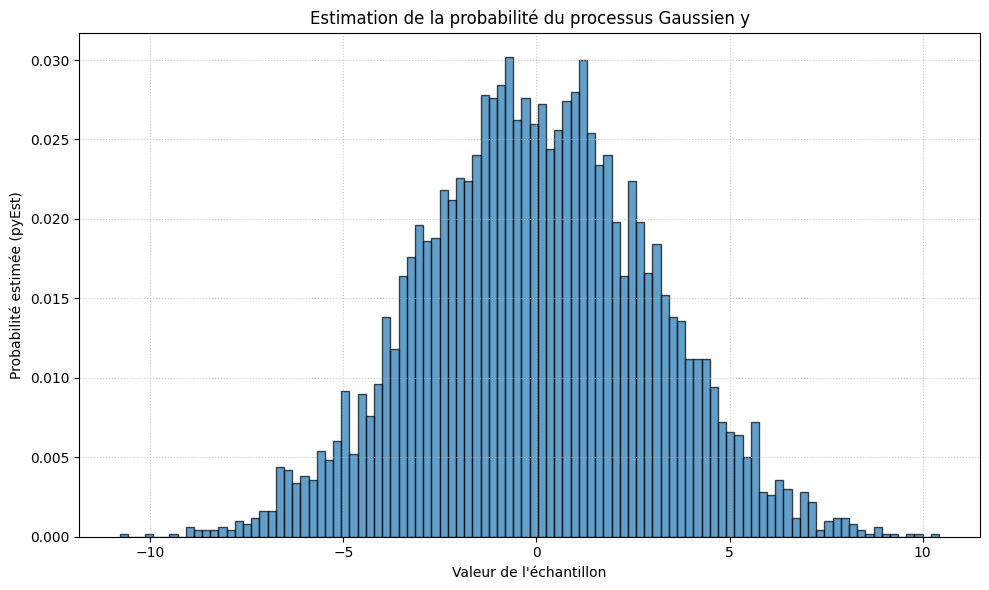

In [ ]:
# 1. Vérification de la somme des probabilités (processus discret x)
print(f"Somme de pxEst : {np.sum(pxEst):.4f} (Attendue : 1.0)")

# 2. Estimation de la probabilité pour le processus Gaussien y
y_flat = y.flatten()

# Calcul de l'histogramme (100 classes)
counts_y, bin_edges = np.histogram(y_flat, bins=100)

# Calcul des centres des classes (plus propre avec np.diff)
centy = bin_edges[:-1] + np.diff(bin_edges) / 2

# Estimation discrète (probabilité)
pyEst = counts_y / (N * NR)

# 3. Affichage graphique
plt.figure(figsize=(10, 6))

bin_width = bin_edges[1] - bin_edges[0]
plt.bar(centy, pyEst, width=bin_width, color='tab:blue', edgecolor='black', alpha=0.7)

plt.xlabel("Valeur de l'échantillon")
plt.ylabel("Probabilité estimée (pyEst)")
plt.title("Estimation de la probabilité du processus Gaussien y")
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
# Vérification : La somme des probabilités doit être égale à 1
print(f"Somme de pyEst (Intégrale discrète) : {np.sum(pyEst):.4f}")

Somme de pyEst (Intégrale discrète) : 1.0000


### 1.3 First order moments in the Sample Space
Calculer la moyenne et l'écart-type pour *chaque instant temporel* (chaque colonne d'échantillon), en utilisant les valeurs des 50 réalisations à cet instant précis. 

**Le concept théorique visé :**
On passe ici au calcul des **moments d'ensemble** (statistiques sur l'espace des réalisations). Au lieu de faire la moyenne le long d'une ligne (dans le temps), on fixe une colonne (un instant précis) et on fait la moyenne sur les 50 univers parallèles. En traitement du signal, c'est ce qui permet de vérifier si un processus est **stationnaire** : si c'est le cas, cette moyenne d'ensemble doit rester globalement constante d'un échantillon à l'autre.

**Méthode demandée en Python :**
La logique s'inverse par rapport aux questions précédentes. On bascule l'opération sur les colonnes en utilisant `axis=0`.

Pour ta matrice `X` (ou `y`) de dimension (50, 100) :
- Moyennes d'ensemble : `np.mean(X, axis=0)` (retourne un vecteur de taille 100).
- Écarts-types d'ensemble : `np.std(X, axis=0, ddof=1)`.

In [15]:
# 1. Calcul des moments d'ensemble (sur l'axe 0 : par instant temporel)
mu_x_s = np.mean(x, axis=0)
std_x_s = np.std(x, axis=0, ddof=1)

# 2. Affichage propre des statistiques pour les 8 premiers échantillons
print("--- Moments d'ensemble des 8 premiers échantillons (Dés) ---")
print(f"{'Échantillon (n)':<16} | {'Moyenne':<12} | {'Écart-type':<12}")
print("-" * 46)
for i, (m, s) in enumerate(zip(mu_x_s[:8], std_x_s[:8])):
    print(f"{i:<16} | {m:<12.4f} | {s:<12.4f}")

--- Moments d'ensemble des 8 premiers échantillons (Dés) ---
Échantillon (n)  | Moyenne      | Écart-type  
----------------------------------------------
0                | 3.3600       | 1.7468      
1                | 3.2000       | 1.6903      
2                | 3.3200       | 1.9319      
3                | 3.5200       | 1.8543      
4                | 4.0000       | 1.7728      
5                | 3.0800       | 1.6517      
6                | 3.1600       | 1.7186      
7                | 3.4600       | 1.6315      


Calcul de l’éspérence de la Moyenne des échantillons mxs et de l’écart-type
stdxS pour chaque échantillon n ( à travers les NR réalisations) :

In [17]:
# Estimation de l'espérance de la moyenne des échantillons
E_mxS = np.mean(mu_x_s)
# Écart-type de la moyenne des échantillons
std_mxS = np.std(mu_x_s, ddof=1)
print(f"\nEspérance estimée (E_mxS) : {E_mxS:.4f}")
print(f"Variation de la moyenne (std_mxS) : {std_mxS:.4f}")


Espérance estimée (E_mxS) : 3.5202
Variation de la moyenne (std_mxS) : 0.2425


### 1.4 Décryptage : Conclusion sur l'Ergodicité

* **Le concept clé (Ergodicité) :** Un processus est dit **ergodique** (du 1er ordre) si ses statistiques temporelles sont égales à ses statistiques d'ensemble. En clair : faire la moyenne sur le temps pour une seule expérience (un seul lancer infini) donne exactement le même résultat que faire la moyenne à un instant $t$ sur une infinité d'expériences parallèles.
* **Le résumé NumPy :**
    * Statistiques temporelles (`axis=1`) $\approx$ Statistiques d'ensemble (`axis=0`) $\implies$ **Processus Ergodique**.

---

### 1.5 `np.cov()` : Matrice de Covariance

* **Contexte & Utilité :** Calcule la matrice de covariance. En traitement du signal, appliquer cela sur ta matrice permet d'analyser la dépendance linéaire entre les différents instants : l'échantillon au temps $t_1$ est-il corrélé avec l'échantillon au temps $t_2$ ?
* **Le paramètre critique (`rowvar=False`) :** C'est le piège numéro 1 de NumPy. Par défaut (`rowvar=True`), la fonction considère que chaque *ligne* est une variable (ex: un capteur) et chaque *colonne* est une observation. Or, dans ton exo (et standard ML), tes lignes sont tes observations (les $NR$ réalisations) et tes colonnes sont tes variables temporelles (les $N$ échantillons). Il faut donc **absolument** passer `rowvar=False` pour inverser ce comportement.
* **Ce qu'elle retourne :** Une matrice carrée et symétrique de dimension $(N, N)$ (donc $100 \times 100$ ici). La diagonale de cette matrice contient les variances de chaque échantillon.
* **Exemple minimal :**

In [18]:
# Calcul de la matrice de covariance Cx (espace des échantillons)
# rowvar=False signifie que chaque colonne est une variable (échantillon)
Cx = np.cov(x, rowvar=False) # Correspond à Cx = cov(x)

#### Visualisation 3D (Équivalent de surf )
Pour reproduire le graphique surf(Cx) présent à la page 11 de votre document , nous utilisons la
fonction plot_surface de Matplotlib.

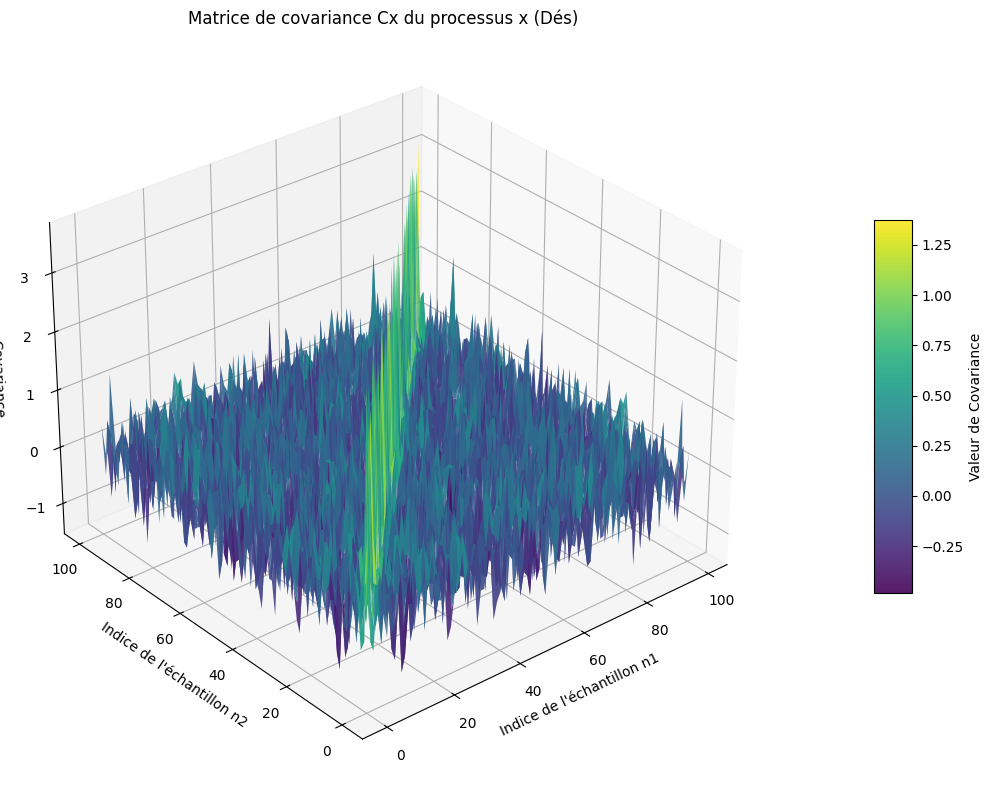

In [20]:
# Création de la grille d'indices temporels (0 à N-1)
n_range = np.arange(N)
X_mesh, Y_mesh = np.meshgrid(n_range, n_range)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Tracé de la surface 3D de la matrice de covariance
surf = ax.plot_surface(X_mesh, Y_mesh, Cx, cmap='viridis', edgecolor='none', alpha=0.9)

# Ajout de la barre de couleur
fig.colorbar(surf, shrink=0.5, aspect=10, label='Valeur de Covariance', pad=0.1)

# Configuration des axes et du titre
ax.set_title('Matrice de covariance Cx du processus x (Dés)')
ax.set_xlabel('Indice de l\'échantillon n1')
ax.set_ylabel('Indice de l\'échantillon n2')
ax.set_zlabel('Covariance')

# Ajustement de l'angle de vue (élévation, azimut)
ax.view_init(elev=30, azim=230)

plt.tight_layout()
plt.show()

### 1.5 Décryptage : Analyse de la matrice de covariance

**Observations sur la matrice de covariance $C_x$ :**
* **Diagonale dominante :** On observe une crête sur la ligne $n_1 = n_2$. Cela représente la variance de chaque échantillon. C'est logique : un échantillon est toujours parfaitement corrélé avec lui-même.
* **Incorrélation temporelle :** En dehors de la diagonale, les valeurs sont quasi nulles. Cela prouve que le lancer de dé à l'instant $t$ n'a aucune influence sur le lancer à l'instant $t+1$. Le processus est dit "blanc".
* **Dimensions :** La matrice est de taille $N \times N$ ($100 \times 100$) car elle exprime la relation entre chaque paire d'instants temporels possibles.

### 1.6 Calcul de la Matrice de Covariance $C_{xR}$
**Rappel technique NumPy pour $C_{xR}$ :**
Par défaut, `np.cov(x)` traite chaque ligne comme une variable. Comme nos données sont structurées en `(NR, N)` (Réalisations $\times$ Échantillons) :
- `np.cov(x)` (ou `rowvar=True`) $\rightarrow$ calcule la covariance entre les **réalisations** ($NR \times NR$).
- `np.cov(x, rowvar=False)` $\rightarrow$ calcule la covariance entre les **échantillons** ($N \times N$).

C'est cette deuxième option ($N \times N$) qui nous intéresse pour l'analyse temporelle du signal.

In [21]:
# Calcul de la matrice de covariance CxR (espace des réalisations)
# En Python, np.cov(x) traite chaque ligne comme une variable par défaut
CxR = np.cov(x) # Résultat : matrice NR x NR (50 x 50)

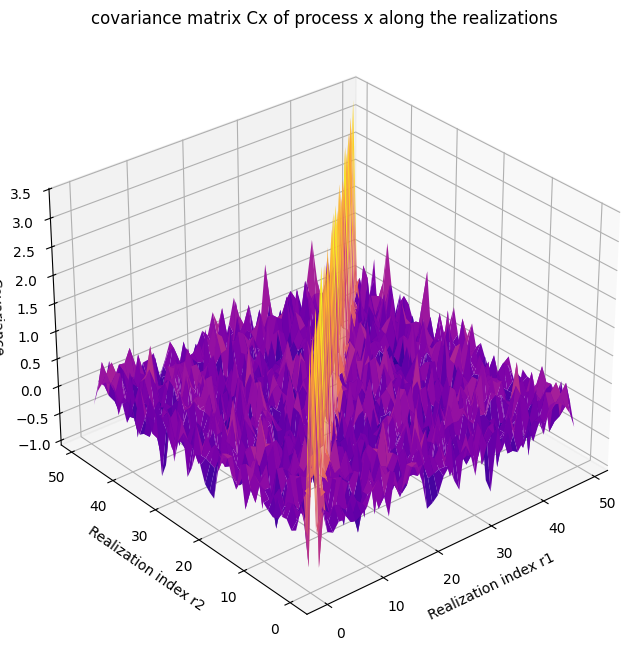

In [22]:
# Création de la grille pour les axes X et Y (indices des réalisations de 0 à NR-1)
NR_range = np.arange(NR)

X_mesh_R, Y_mesh_R = np.meshgrid(NR_range, NR_range)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Tracé de la surface 3D
ax.plot_surface(X_mesh_R, Y_mesh_R, CxR, cmap='plasma', edgecolor='none')
# Configuration des labels et du titre
ax.set_title('covariance matrix Cx of process x along the realizations')
ax.set_xlabel('Realization index r1')
ax.set_ylabel('Realization index r2')
ax.set_zlabel('Covariance')
# Ajustement de la vue pour correspondre aux graphiques du document
ax.view_init(elev=30, azim=230)
plt.show()

Analyser la matrice de covariance $C_{xR}$ calculée entre les différentes réalisations (les lignes).

**Le concept théorique visé :**
L'indépendance des expériences. Dans un processus stochastique, chaque réalisation (chaque ligne de ta matrice) est générée de manière autonome. On vérifie ici qu'il n'existe aucun lien statistique entre l'expérience $i$ et l'expérience $j$.

**Points clés de l'analyse :**
- **Diagonale dominante :** On observe une crête sur la diagonale qui correspond à la variance de chaque réalisation.
- **Incorrélation :** Les valeurs hors-diagonale sont quasi nulles, confirmant que les réalisations sont statistiquement indépendantes les unes des autres.
- **Dimensions :** La matrice est de taille $NR \times NR$ ($50 \times 50$) car elle compare les 50 lignes de la matrice `x` entre elles.

### 1.7 Take the process y and do the same as before for x
Calculer la matrice de covariance $C_y$ du processus Gaussien $y$. L'objectif est d'obtenir une matrice de dimension $NR \times NR$ représentant la covariance entre les différentes réalisations. Pour cela, la fonction attend en entrée une matrice de format $N \times NR$ (où chaque colonne est une réalisation et chaque ligne un échantillon temporel).

**Détails techniques :**
- **Format d'entrée :** Si ta matrice `y` est initialement au format $(NR, N)$, tu dois utiliser sa transposée `y.T` pour correspondre au format $N \times NR$ demandé par cette consigne spécifique.
- **Symétrie :** La matrice $C_y$ est mathématiquement symétrique ($C_y = C_y^T$). L'élément $C_y(i,j)$ est identique à $C_y(j,i)$.
- **Analyse de la diagonale :** Les valeurs $C_y(i,i)$ sur la diagonale sont très supérieures aux autres car elles représentent la variance de chaque réalisation (auto-corrélation). Comme les réalisations sont indépendantes, la covariance entre deux réalisations distinctes ($i \neq j$) est théoriquement nulle, ce qui explique pourquoi les valeurs hors-diagonale sont très faibles.
- **Calcul Python :** S'effectue via `np.cov(y.T, rowvar=False)` ou simplement `np.cov(y)` (puisque par défaut `rowvar=True` calcule la covariance entre les lignes).

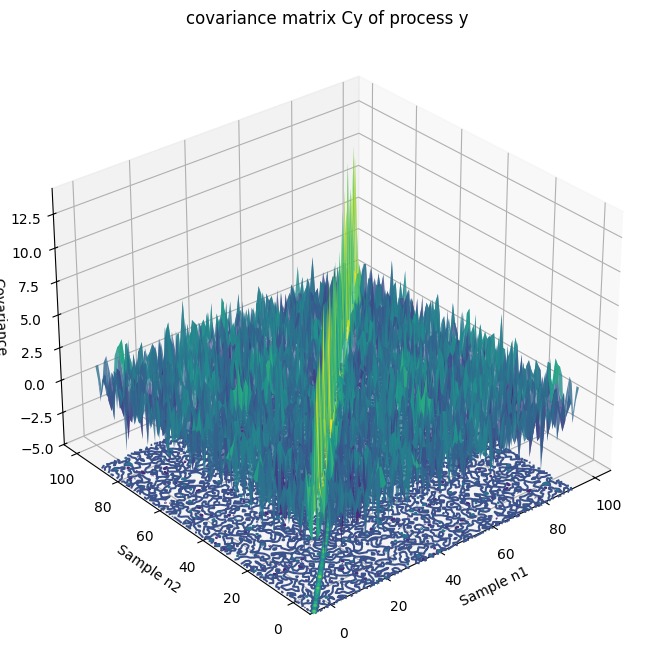

In [23]:
# Calcul de la matrice de covariance Cy (échantillons)
# rowvar=False car les échantillons sont en colonnes dans le calcul statistique
Cy = np.cov(y, rowvar=False) # Correspond à cy = cov(y)
# Visualisation 3D (équivalent à surfc)
N_range = np.arange(N)
X, Y = np.meshgrid(N_range, N_range)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
# plot_surface avec un contour pour simuler surfc()
surf = ax.plot_surface(X, Y, Cy, cmap='viridis', edgecolor='none', alpha=0.8)
cset = ax.contour(X, Y, Cy, zdir='z', offset=np.min(Cy)-2, cmap='viridis')
ax.set_title('covariance matrix Cy of process y')
ax.set_xlabel('Sample n1')
ax.set_ylabel('Sample n2')
ax.set_zlabel('Covariance')
ax.view_init(elev=30, azim=230)
plt.show()

### 1.8 Décryptage : Matrice de covariance $C_{yR}$ et visualisation 3D

Calculer et afficher en relief (3D) la matrice de covariance qui compare les 50 réalisations du processus gaussien entre elles. L'objectif est de vérifier visuellement si une expérience influe sur une autre.

* **Le concept théorique visé :** **L'indépendance des réalisations.** Dans un processus stochastique idéal, ce qui se passe dans la réalisation n°1 n'a aucun lien avec la réalisation n°2. La matrice doit donc montrer que chaque série n'est corrélée qu'avec elle-même.

* **Analyse de la visualisation :**
    * **Dimensions :** $NR \times NR$ ($50 \times 50$).
    * **La "Crête" diagonale :** Le graphique 3D doit afficher une ligne de sommets très marqués sur la diagonale, représentant la variance de chaque série.
    * **La "Plaine" :** Tout le reste du graphique (hors-diagonale) doit être proche de zéro, confirmant que les séries sont décorrélées.

* **Rappel technique NumPy :** Pour obtenir ce format $NR \times NR$ à partir de ta matrice `y` de dimension $(NR, N)$, tu calcules la covariance entre les lignes. En Python, c'est le comportement par défaut : `np.cov(y)`.

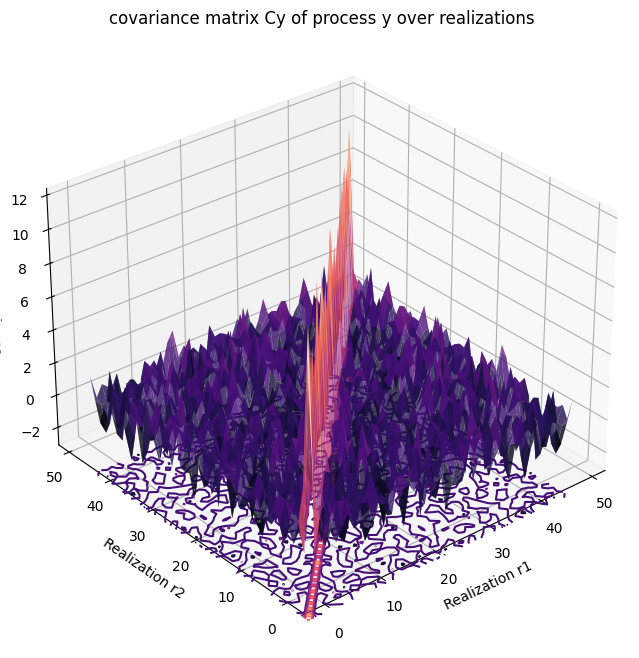

In [24]:
# Calcul de la matrice de covariance CyR (réalisations)
# np.cov(y) calcule la covariance entre les lignes (réalisations)
CyR = np.cov(y)
# Visualisation 3D
NR_range = np.arange(NR)
XR, YR = np.meshgrid(NR_range, NR_range)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surfR = ax.plot_surface(XR, YR, CyR, cmap='magma', edgecolor='none', alpha=0.8)
csetR = ax.contour(XR, YR, CyR, zdir='z', offset=np.min(CyR)-2, cmap='magma')
ax.set_title('covariance matrix Cy of process y over realizations')
ax.set_xlabel('Realization r1')
ax.set_ylabel('Realization r2')
ax.set_zlabel('Covariance')
ax.view_init(elev=30, azim=230)
plt.show()

### 1.9 Décryptage : Analyse finale du processus Gaussien y (1.9)

* **Interprétation de la diagonale ($C_y$) :** Les valeurs sur la diagonale de la matrice de covariance temporelle tournent autour de 9. C'est cohérent avec la théorie : l'écart-type $A$ était fixé à 3, donc la variance (ou puissance du signal) est $\sigma^2 = A^2 = 9$.

* **Le concept de Bruit Blanc Gaussien :** L'incorrélation temporelle observée (valeurs hors-diagonale proches de zéro) confirme que le processus est un **bruit blanc**. Cela signifie que la valeur prise par l'échantillon à l'instant $n$ ne donne aucune information sur la valeur à l'instant $n+1$.

* **Indépendance des réalisations ($C_{yR}$) :** Le fait que la matrice de covariance entre réalisations soit également diagonale confirme que chaque expérience (chaque ligne de ta matrice) est générée de manière totalement isolée des autres.

* **Résumé des dimensions :**
    - $C_y$ est de taille $100 \times 100$ (corrélation entre instants temporels).
    - $C_{yR}$ est de taille $50 \times 50$ (corrélation entre expériences/réalisations).

### 1.10 — Filtrage d'un processus aléatoire

L'objectif est d'observer l'effet d'un filtre linéaire sur un processus aléatoire `y` (bruit blanc gaussien). Filtrer un bruit blanc revient à le « colorier » : le filtre introduit de la mémoire et modifie la densité spectrale de puissance (DSP) ainsi que la fonction d'autocorrélation.

Deux types de filtres passe-bas sont comparés :

- **a) Filtre FIR** — Moyenne mobile (Moving Average) à 10 coefficients  
  → Réponse impulsionnelle finie, pas de rétroaction, toujours stable.

- **b) Filtre IIR** — Approximation de Butterworth du 2ème ordre, fréquence de coupure normalisée `Wn = 0.1`  
  → Réponse impulsionnelle infinie, avec rétroaction (pôles), transition plus sélective que le FIR.

**Définition des coefficients du filtre FIR (Moyenne Mobile, 10 taps)**

Un filtre à moyenne mobile calcule la moyenne des 10 derniers échantillons. Tous les coefficients sont égaux à `1/10`, ce qui donne un poids identique à chaque échantillon passé.

> **Pourquoi `b = ones(10)/10` ?**  
> La sortie du filtre est : `y_f[n] = (x[n] + x[n-1] + ... + x[n-9]) / 10`  
> C'est la définition d'une moyenne glissante : chaque sortie est la moyenne des 10 entrées précédentes.

> **À noter :** Le dénominateur `a = 1` signifie qu'il n'y a aucun pôle (pas de terme récursif). La stabilité est garantie.

In [25]:
# --- Définition du filtre FIR MA 10 taps ---
# Numérateur : [0.1, 0.1, ..., 0.1] (10 fois)
num_ma = np.ones(10) / 10
# Dénominateur : [1] pour un filtre FIR
den_ma = [1]
# Affichage de la réponse impulsionnelle théorique
print(f"Coefficients du filtre FIR : {num_ma}")

Coefficients du filtre FIR : [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


**Test du filtre avec un échelon unité**

Pour valider et visualiser le comportement du filtre, on remplace la première réalisation du processus `y` par un **échelon unité** : le signal vaut 0 pour la première moitié des échantillons, puis 1 pour la seconde moitié.

> **Pourquoi un échelon ?**  
> L'échelon est un signal de test classique : il permet de voir comment le filtre réagit à une transition brutale. La réponse à l'échelon révèle directement la "mémoire" du filtre — plus le filtre est long, plus la montée est progressive.

**Ce que l'on attend :**
- Pour le **filtre FIR MA 10 taps** : une montée linéaire progressive sur 10 échantillons, puis stabilisation à 1. Pas de dépassement (pas d'overshoot).
- Pour le **filtre IIR Butterworth** : une montée plus douce avec un léger dépassement (overshoot) et des oscillations transitoires avant stabilisation, caractéristiques d'un filtre récursif d'ordre 2.

> **À noter :** On ne modifie qu'une seule réalisation pour le test — les autres restent du bruit blanc. Cela permet de comparer côte à côte le signal original (échelon) et le signal filtré.

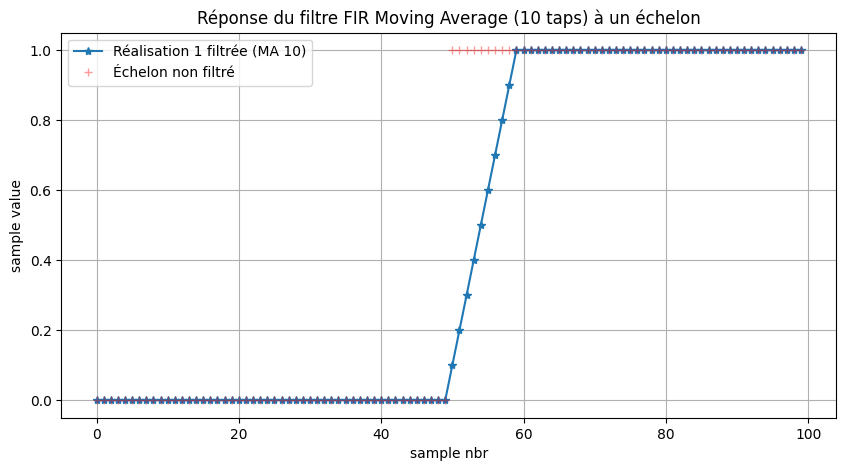

In [26]:
# Préparation du signal de test (réalisation 1 = échelon à n=50)
y_step_test = y.copy()
y_step_test[0, :] = np.concatenate([np.zeros(N//2), np.ones(N//2)])

# Application du filtrage FIR
# yf_ma est la matrice des signaux filtrés
yf_ma = signal.lfilter(num_ma, den_ma, y_step_test, axis=1)

# Visualisation de la réponse
plt.figure(figsize=(10, 5))
plt.plot(np.arange(N), yf_ma[0, :], '-*', label='Réalisation 1 filtrée (MA 10)')
plt.plot(np.arange(N), y_step_test[0, :], 'r+', label='Échelon non filtré', alpha=0.4)
plt.title('Réponse du filtre FIR Moving Average (10 taps) à un échelon')
plt.xlabel('sample nbr')
plt.ylabel('sample value')
plt.legend()
plt.grid(True)
plt.show()

**Analyse de l'autocorrélation du signal filtré**

Le filtrage MA modifie radicalement l'autocorrélation du bruit blanc original `y`. 

**Rappel :** un bruit blanc a une autocorrélation en forme d'impulsion de Dirac (corrélation nulle pour tout décalage ≠ 0). Après filtrage MA, le signal filtré a une **mémoire** : chaque échantillon dépend des 9 précédents.

> **Pour un filtre MA à 10 taps, l'autocorrélation théorique prend une forme triangulaire** de largeur 10 échantillons — elle est maximale en 0 et décroît linéairement jusqu'à s'annuler au lag 10.

C'est une conséquence directe de la relation : `R_yf(k) = h(k) * h(-k) * R_y(k)`, où la convolution de la réponse impulsionnelle rectangulaire avec elle-même donne un triangle.

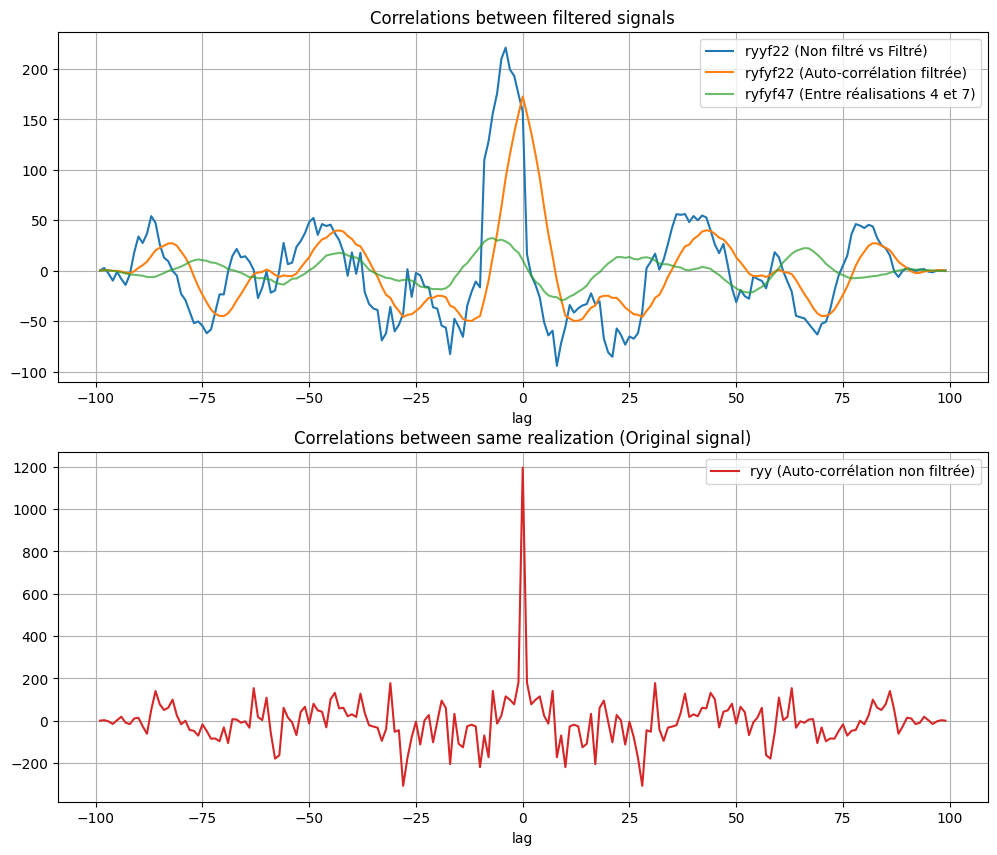

In [27]:
yf_ma = signal.lfilter(num_ma, den_ma, y, axis=1)

# Fonction pour simuler le xcorr de MATLAB (avec lags)
def xcorr_python(a, b):
    # On centre les signaux (soustraction de la moyenne) pour la corrélation
    a_centered = a - np.mean(a)
    b_centered = b - np.mean(b)
    corr = signal.correlate(a_centered, b_centered, mode='full')
    lags = np.arange(-len(a) + 1, len(a))
    return corr, lags

# 1. Corrélation entre 2 instants (échantillons 1 et 2) à travers toutes les réalisations
ryf12R, lagR = xcorr_python(yf_ma[:, 0], yf_ma[:, 1])

# 2. Autocorrélation pour une seule réalisation (la n°2)
ryfyf22, lag = xcorr_python(yf_ma[1, :], yf_ma[1, :])

# 3. Corrélation entre deux réalisations filtrées différentes (la n°4 et la n°7)
ryfyf47, _ = xcorr_python(yf_ma[3, :], yf_ma[6, :])

# 4. Corrélation entre l'échantillon non filtré et filtré pour la même réalisation (n°2)
ryyf22, _ = xcorr_python(y[1, :], yf_ma[1, :])

# 5. Autocorrélation du signal non filtré (pour comparaison)
ryy22, _ = xcorr_python(y[1, :], y[1, :])

# Affichage des graphiques
plt.figure(figsize=(12, 10))

# Premier sous-graphique : Corrélations du signal filtré
plt.subplot(2, 1, 1)
plt.plot(lag, ryyf22, label='ryyf22 (Non filtré vs Filtré)')
plt.plot(lag, ryfyf22, label='ryfyf22 (Auto-corrélation filtrée)')
plt.plot(lag, ryfyf47, label='ryfyf47 (Entre réalisations 4 et 7)', alpha=0.7)
plt.title('Correlations between filtered signals')
plt.xlabel('lag')
plt.legend()
plt.grid(True)

# Deuxième sous-graphique : Autocorrélation du signal original
plt.subplot(2, 1, 2)
plt.plot(lag, ryy22, color='tab:red', label='ryy (Auto-corrélation non filtrée)')
plt.title('Correlations between same realization (Original signal)')
plt.xlabel('lag')
plt.legend()
plt.grid(True)

**Analyse des résultats**

**Lissage des corrélations :** Le signal filtré `ryfyf22` présente une autocorrélation beaucoup plus large et lisse que celle du signal original `ryy22`. C'est l'effet direct du filtre MA : en moyennant 10 échantillons consécutifs, il introduit une dépendance temporelle — chaque sortie "se souvient" des 9 entrées précédentes.

**Pic d'autocorrélation :** Le bruit blanc original a un pic en impulsion très fin centré en lag = 0 (échantillons non corrélés entre eux). Après filtrage, ce pic s'étale sur une largeur de 10 lags, reflétant la mémoire du filtre.

**Indépendance des réalisations :** La courbe `ryfyf47` (corrélation entre les réalisations 4 et 7) reste centrée autour de zéro. Cela confirme que le filtrage n'introduit pas de lien statistique entre les différentes réalisations — elles restent indépendantes les unes des autres.

### 1.12 — Visualisation de la matrice de covariance du processus filtré

L'objectif est de visualiser concrètement l'effet du filtrage sur la structure statistique du processus, à travers deux matrices de covariance :

- **`Cyf` (espace échantillons) :** covariance entre les instants temporels, calculée à travers les réalisations. On s'attend à voir une **structure en bande autour de la diagonale** (largeur ≈ 10), preuve que le filtre MA a introduit une corrélation entre échantillons voisins.

- **`CyfR` (espace réalisations) :** covariance entre les réalisations, calculée à travers les échantillons. On s'attend à une **matrice quasi-diagonale**, confirmant que les réalisations restent statistiquement indépendantes après filtrage.

> On utilise la matrice `yf_ma` déjà calculée : le processus gaussien `y` (bruit blanc) passé à travers le filtre MA 10 taps.

> **Rappel :** Avant filtrage, `Cy` était une matrice diagonale pure (bruit blanc = zéro corrélation entre échantillons). La comparaison avant/après illustre directement l'effet de la mémoire introduite par le filtre.

In [28]:
# 1. Matrice de covariance dans l'espace des échantillons (Cyf)
# Correspond à cyf = cov(yf) en MATLAB
# Taille : N x N (100 x 100)
Cyf_ma = np.cov(yf_ma, rowvar=False)
# 2. Matrice de covariance dans l'espace des réalisations (CyfR)
# Correspond à CyfR = cov(yf') en MATLAB
# Taille : NR x NR (50 x 50)
CyfR_ma = np.cov(yf_ma)

## 1.13 — Visualisation 3D : Matrice de covariance `Cyf` (espace échantillons)

On représente en 3D la matrice `Cyf` pour visualiser la structure de corrélation introduite par le filtre MA.

> **Ce que l'on observe :** Une "crête" le long de la diagonale principale, avec un étalement sur environ 10 échantillons de part et d'autre. Cela traduit directement la mémoire du filtre : deux échantillons séparés de moins de 10 instants sont corrélés, au-delà ils ne le sont plus.

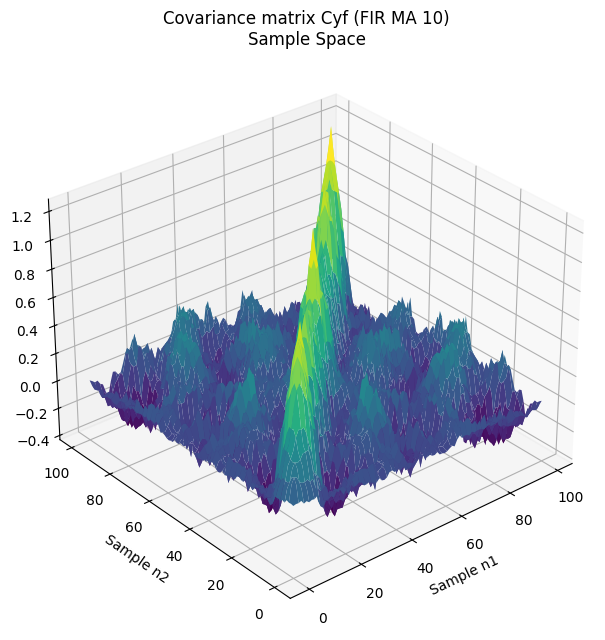

In [29]:
# Grille pour les échantillons (100x100)
X_f, Y_f = np.meshgrid(np.arange(N), np.arange(N))
fig = plt.figure(figsize=(12, 8))
# --- Graphique 1 : Covariance Espace Échantillons ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_f, Y_f, Cyf_ma, cmap='viridis', edgecolor='none')
ax1.set_title('Covariance matrix Cyf (FIR MA 10)\nSample Space')
ax1.set_xlabel('Sample n1')
ax1.set_ylabel('Sample n2')
ax1.view_init(elev=30, azim=230)
plt.tight_layout()
plt.show()

### 1.14 — Visualisation 3D : Matrice de covariance `CyfR` (espace réalisations)

On représente en 3D la matrice `CyfR` pour vérifier l'indépendance entre réalisations après filtrage.

> **Ce que l'on observe :** Une matrice quasi-diagonale, identique à celle du processus non filtré. Le filtrage n'introduit aucune corrélation entre les réalisations — chaque réalisation reste statistiquement indépendante des autres.

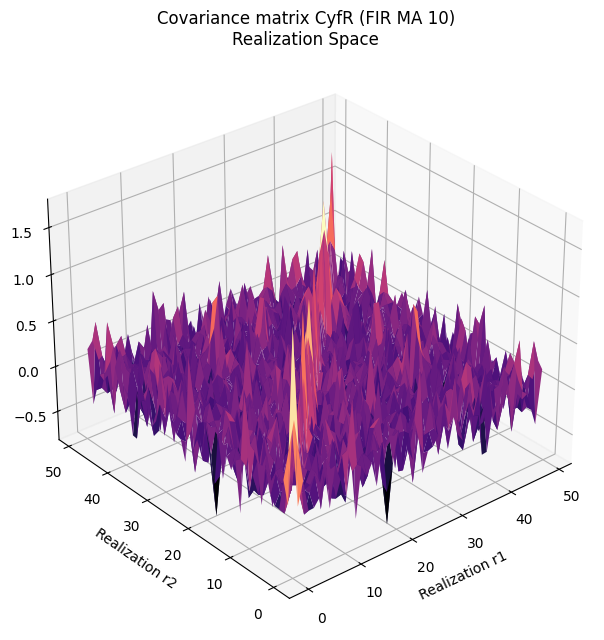

In [31]:
# Grille pour les réalisations (50x50)
XR_f, YR_f = np.meshgrid(np.arange(NR), np.arange(NR))
# --- Graphique 2 : Covariance Espace Réalisations ---
fig = plt.figure(figsize=(12, 8))
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(XR_f, YR_f, CyfR_ma, cmap='magma', edgecolor='none')
ax2.set_title('Covariance matrix CyfR (FIR MA 10)\nRealization Space')
ax2.set_xlabel('Realization r1')
ax2.set_ylabel('Realization r2')
ax2.view_init(elev=30, azim=230)
plt.tight_layout()
plt.show()

### 1.15 — Analyse comparative

**Corrélation temporelle `Cyf` :** Contrairement au bruit blanc original dont la covariance était nulle hors diagonale, on observe une structure élargie le long de la diagonale — sur une largeur de 10 échantillons. Cela prouve que le filtre MA a introduit une mémoire : chaque échantillon dépend des 9 précédents.

**Indépendance des réalisations `CyfR` :** La matrice reste quasi-diagonale, identique à celle du processus non filtré. Filtrer chaque réalisation séparément ne crée aucun lien statistique entre elles.

> **Conclusion :** Le filtre MA agit uniquement dans la dimension temporelle — il corrèle les échantillons voisins sans jamais coupler les réalisations entre elles.

### 1.16 — Filtrage avec un filtre IIR Butterworth du 2ème ordre

**Définition des coefficients du filtre IIR Butterworth**

On utilise `scipy.signal.butter` pour concevoir un filtre passe-bas IIR Butterworth d'ordre 2, avec une fréquence de coupure normalisée `Wn = 0.1` (soit 10% de la fréquence d'échantillonnage).

> **Pourquoi Butterworth ?**  
> Le filtre de Butterworth est dit "maximalement plat" dans la bande passante — pas d'ondulations. Il est défini par ses pôles (dénominateur `Den`) et zéros (numérateur `Num`), contrairement au FIR qui n'a que des zéros.

**Test avec un échelon unité :** comme pour le FIR, on injecte un échelon sur la première réalisation pour observer la réponse temporelle du filtre.

> **Ce que l'on attend :**  
> Contrairement au FIR MA qui montait linéairement sans dépassement, le filtre IIR Butterworth présente une montée plus douce avec un léger **overshoot** et des oscillations transitoires avant stabilisation — comportement typique d'un filtre récursif d'ordre 2.

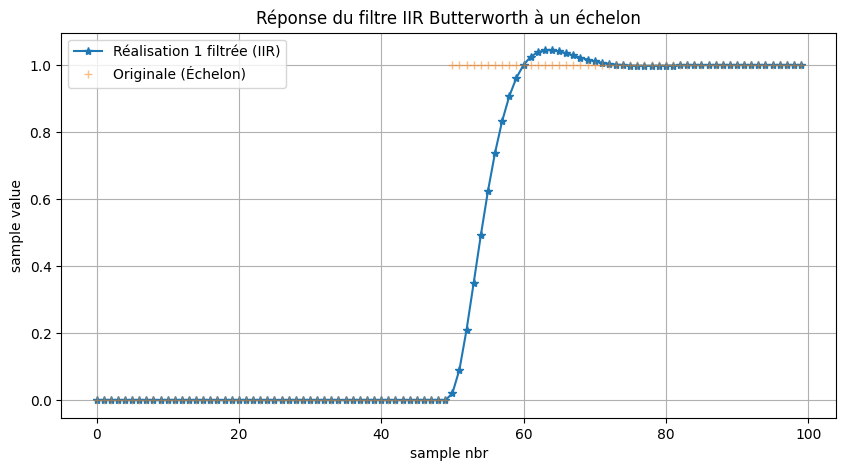

In [32]:
# --- Paramètres du filtre IIR ---
Wn = 0.1
Num, Den = signal.butter(2, Wn, 'low')
# --- Test du filtre avec un échelon (Page 15) ---
y_step_test = y.copy()
y_step_test[0, :] = np.concatenate([np.zeros(N//2), np.ones(N//2)])
# Application du filtre sur la réalisation test
yf_test = signal.lfilter(Num, Den, y_step_test[0, :]) #
plt.figure(figsize=(10, 5))
plt.plot(yf_test, '-*', label='Réalisation 1 filtrée (IIR)')
plt.plot(y_step_test[0, :], '+', label='Originale (Échelon)', alpha=0.5)
plt.title('Réponse du filtre IIR Butterworth à un échelon')
plt.xlabel('sample nbr')
plt.ylabel('sample value')
plt.legend()
plt.grid(True)
plt.show()

### 1.17 — Application du filtre IIR Butterworth sur le processus complet

On applique le filtre IIR Butterworth (coefficients `Num` et `Den` définis en 1.16.1) sur l'ensemble de la matrice `y`, c'est-à-dire sur toutes les réalisations simultanément (`axis=1` pour filtrer chaque réalisation indépendamment le long de l'axe temporel).

> Le résultat `yf_iir` est une matrice de même dimension que `y` : chaque ligne est une réalisation du processus filtrée par le Butterworth.

In [33]:
# Filtrage de la matrice complète (axis=1 pour traiter chaque réalisation)
yf_iir = signal.lfilter(Num, Den, y, axis=1)

### 1.18 — Analyse des corrélations du signal filtré (IIR Butterworth)

On calcule les mêmes corrélations qu'en 1.10.3, mais cette fois sur le signal filtré `yf_iir` :

- **`ryf12R`** : corrélation entre les échantillons 1 et 2 à travers toutes les réalisations
- **`ryfyf22`** : autocorrélation d'une seule réalisation filtrée (n°2)
- **`ryfyf47`** : corrélation entre deux réalisations filtrées différentes (n°4 et n°7)
- **`ryyf22`** : corrélation entre le signal non filtré et filtré (réalisation n°2)

> **Ce que l'on attend par rapport au FIR :**  
> La réponse impulsionnelle du Butterworth étant infinie et oscillante, l'autocorrélation `ryfyf22` sera plus étalée et présentera des lobes secondaires — reflet des oscillations du filtre. La corrélation entre réalisations `ryfyf47` restera centrée en zéro, confirmant leur indépendance.

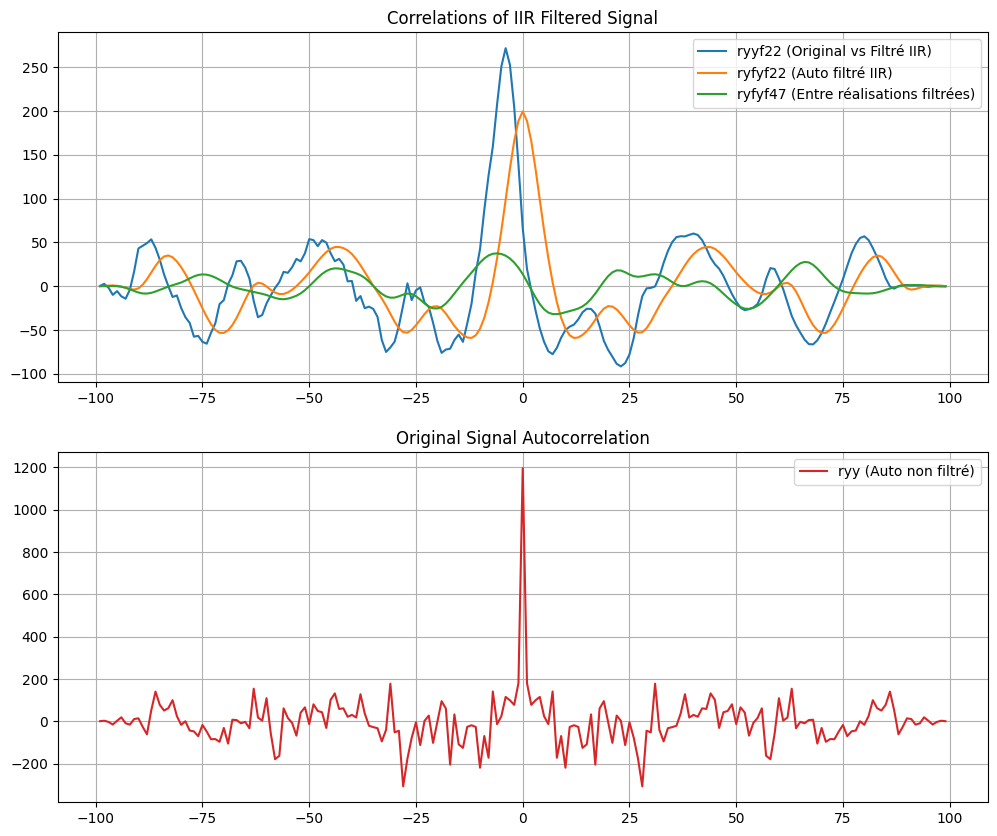

In [34]:
def xcorr_python(a, b):
    a_centered = a - np.mean(a)
    b_centered = b - np.mean(b)
    corr = signal.correlate(a_centered, b_centered, mode='full')
    lags = np.arange(-len(a) + 1, len(a))
    return corr, lags

# a) Corrélation entre 2 instants (échantillons 1 et 2) sur toutes les réalisations
ryf12R, lagR = xcorr_python(yf_iir[:, 0], yf_iir[:, 1])

# b) Autocorrélation de la réalisation 2 filtrée
ryfyf22, lag = xcorr_python(yf_iir[1, :], yf_iir[1, :])

# c) Corrélation entre deux réalisations filtrées différentes (4 et 7)
ryfyf47, _ = xcorr_python(yf_iir[3, :], yf_iir[6, :])

# d) Corrélation entre le signal non filtré et filtré (réalisation 2)
ryyf22, _ = xcorr_python(y[1, :], yf_iir[1, :])

# e) Autocorrélation du signal original (non filtré) pour comparaison
ryy22, _ = xcorr_python(y[1, :], y[1, :])

# Affichage
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(lag, ryyf22, label='ryyf22 (Original vs Filtré IIR)')
plt.plot(lag, ryfyf22, label='ryfyf22 (Auto filtré IIR)')
plt.plot(lag, ryfyf47, label='ryfyf47 (Entre réalisations filtrées)')
plt.title('Correlations of IIR Filtered Signal')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(lag, ryy22, color='tab:red', label='ryy (Auto non filtré)')
plt.title('Original Signal Autocorrelation')
plt.legend()
plt.grid(True)
plt.show()

### 1.19 — Matrices de covariance 3D (filtre IIR Butterworth)

On visualise en 3D les matrices `Cyf` et `CyfR` du processus filtré par le Butterworth, de la même façon qu'en 1.13 et 1.14 pour le FIR.

> **Ce que l'on attend par rapport au FIR :**  
> - **`Cyf` (espace échantillons) :** La bande de corrélation autour de la diagonale sera plus large et plus riche en relief, avec des zones de corrélation négative légère — reflet des oscillations de la réponse impulsionnelle du Butterworth.  
> - **`CyfR` (espace réalisations) :** La matrice reste diagonale, les réalisations demeurent indépendantes.

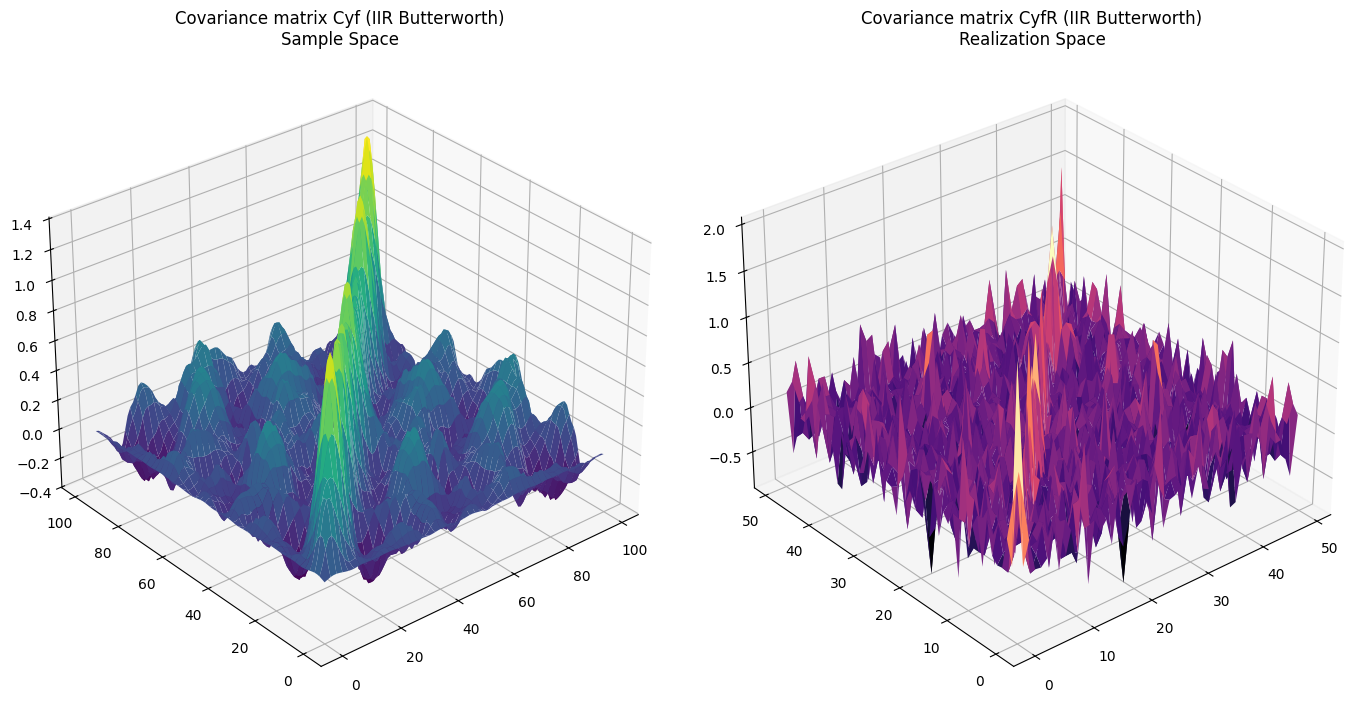

In [36]:
# Calcul des matrices
Cyf_iir = np.cov(yf_iir, rowvar=False) # Espace des échantillons
CyfR_iir = np.cov(yf_iir)
# Espace des réalisations
# --- Affichage 3D ---
fig = plt.figure(figsize=(14, 7))
# Matrice de covariance - Espace Échantillons
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
X, Y = np.meshgrid(np.arange(N), np.arange(N))
ax1.plot_surface(X, Y, Cyf_iir, cmap='viridis', edgecolor='none')
ax1.set_title('Covariance matrix Cyf (IIR Butterworth)\nSample Space')
ax1.view_init(elev=30, azim=230)
# Matrice de covariance - Espace Réalisations
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
XR, YR = np.meshgrid(np.arange(NR), np.arange(NR))
ax2.plot_surface(XR, YR, CyfR_iir, cmap='magma', edgecolor='none')
ax2.set_title('Covariance matrix CyfR (IIR Butterworth)\nRealization Space')
ax2.view_init(elev=30, azim=230)
plt.tight_layout()
plt.show()

### 1.20 — Observations spécifiques au filtre IIR Butterworth

**Réponse temporelle :** Contrairement au filtre FIR dont la réponse à l'échelon est monotone (montée linéaire sans dépassement), le filtre IIR présente un **overshoot** suivi d'oscillations amorties avant stabilisation — comportement typique d'un système récursif d'ordre 2.

**Structure de corrélation `Cyf` :** La diagonale est plus riche en relief que pour le FIR. On observe des zones de **corrélation négative légère** de part et d'autre de la diagonale, directement liées aux oscillations de la réponse impulsionnelle du Butterworth.

**Indépendance des réalisations `CyfR` :** La matrice reste diagonale — le filtrage IIR, comme le FIR, ne crée aucun couplage statistique entre les réalisations.

> **Conclusion générale :** Les deux filtres colorient le bruit blanc et introduisent de la mémoire temporelle, mais le IIR Butterworth produit une structure de corrélation plus complexe (oscillations, corrélations négatives) là où le FIR MA produisait un simple triangle symétrique.